In [1]:
!pip install -q segmentation-models-pytorch timm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 10.0 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn as nn
import segmentation_models_pytorch as smp

# 1. Model Architecture Definition
def create_deepflash2_model(in_channels=3, num_classes=2):
    """
    Creates the default deepflash2 U-Net architecture.
    """
    # deepflash2 uses a U-Net with a ConvNext Tiny encoder
    model = smp.Unet(
        encoder_name="tu-convnext_tiny", # 'tu-' prefix uses the timm library in SMP
        encoder_weights="imagenet",      # ImageNet pretraining
        in_channels=in_channels,
        classes=num_classes,
    )

    # Initialize segmentation head with truncated normal distribution
    for module in model.decoder.modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            nn.init.trunc_normal_(module.weight, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)

    return model


# 2. Loss Function
class Deepflash2Loss(nn.Module):
    def __init__(self):
        super().__init__()
        # Mean of cross-entropy and Dice loss
        self.ce_loss = nn.CrossEntropyLoss()
        self.dice_loss = smp.losses.DiceLoss(smp.losses.MULTICLASS_MODE)

    def forward(self, y_pred, y_true):
        return (self.ce_loss(y_pred, y_true) + self.dice_loss(y_pred, y_true)) / 2.0


# 3. Training Loop (resembling fastai fine_tune policy)
def train_model(model, train_loader, optimizer, device):
    """
    Trains a single model following the fastai fine-tune policy.
    """
    criterion = Deepflash2Loss()
    model.to(device)

    # Phase 1: Freeze encoder weights (one epoch)
    for param in model.encoder.parameters():
        param.requires_grad = False

    model.train()
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()

    # Phase 2: Unfreeze weights and train (25 epochs)
    for param in model.encoder.parameters():
        param.requires_grad = True

    for epoch in range(25): # 25 epochs as defined in the paper
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()

    return model


# 4. Ensemble & Uncertainty Estimation (Testing)
def tta_predict(model, x):
    """
    Applies Test-Time Augmentations (TTA) during prediction.
    """
    # M=5 models and T=4 augmentations
    # Simple TTA: Original, Rotate 90, Rotate 180, Rotate 270
    preds = []
    for k in range(4): # T=4
        x_aug = torch.rot90(x, k=k, dims=[2, 3])
        pred_aug = torch.softmax(model(x_aug), dim=1)
        # Reverse augmentation to align spatial dimensions
        pred = torch.rot90(pred_aug, k=-k, dims=[2, 3])
        preds.append(pred)
    return torch.stack(preds) # Shape: [T, Batch, Classes, H, W]

def ensemble_uncertainty_estimation(ensemble_models, x, num_classes):
    """
    Calculates hybrid uncertainty (epistemic + aleatoric) across M models and T augmentations.
    """
    all_preds = []
    for model in ensemble_models:
        model.eval()
        with torch.no_grad():
            # Get T=4 predictions for this specific model
            preds_t = tta_predict(model, x) # Shape: [T, B, C, H, W]
            all_preds.append(preds_t)

    # Stack all predictions: Shape [M, T, B, C, H, W]
    all_preds = torch.stack(all_preds)

    # 1. Mean prediction across M models and T augs (Equation 1)
    mean_pred = all_preds.mean(dim=(0, 1))

    # 2. Aleatoric Uncertainty
    # mean over T and M of [p - p^2]
    aleatoric = (all_preds - all_preds**2).mean(dim=(0, 1))

    # 3. Epistemic Uncertainty
    # mean over T and M of [(p - mean_pred)^2]
    epistemic = ((all_preds - mean_pred.unsqueeze(0).unsqueeze(0))**2).mean(dim=(0, 1))

    # 4. Hybrid variance per class (Equation 3)
    var_k = aleatoric + epistemic

    # 5. Aggregate multiclass uncertainty map (Equation 4)
    # Zeta scaling factor is 4 in their experiments
    zeta = 4
    uncertainty_map = (zeta / num_classes) * var_k.sum(dim=1) # Sum over classes

    return mean_pred, uncertainty_map

In [5]:
import os
import glob
import cv2
import torch
import numpy as np
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
from sklearn.model_selection import KFold

# ---------------------------------------------------------
# 1. Dataset Loading
# ---------------------------------------------------------
# class CFOSDataset(Dataset):
#     def __init__(self, image_dir, mask_dir=None, transform=None):
#         self.image_paths = sorted(glob.glob(os.path.join(image_dir, '*.*')))
#         self.mask_dir = mask_dir
#         self.transform = transform

#     def __len__(self):
#         return len(self.image_paths)

#     def __getitem__(self, idx):
#         img_path = self.image_paths[idx]
#         # Load image (assuming 1-channel grayscale or 3-channel RGB)
#         image = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
#         if image is None: # Added check for missing image
#             raise FileNotFoundError(f"Missing image: {img_path}")

#         if len(image.shape) == 2:
#             image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)

#         # Normalize to [0, 1] and reshape to [C, H, W]
#         image = image.astype(np.float32) / 255.0
#         image = np.transpose(image, (2, 0, 1))

#         if self.mask_dir:
#             basename = os.path.basename(img_path)
#             mask_path = os.path.join(self.mask_dir, basename)
#             mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

#             if mask is None: # Added check for missing mask
#                 # Return a zero mask of the same spatial dimensions as the image
#                 mask = np.zeros(image.shape[1:], dtype=np.int64)
#             else:
#                 # Binarize mask (assuming background=0, foreground>0)
#                 mask = (mask > 0).astype(np.int64)
#             return torch.tensor(image), torch.tensor(mask)

#         return torch.tensor(image), img_path
class CFOSDataset(Dataset):
    def __init__(self, image_dir, mask_dir=None, transform=None):
        self.image_paths = sorted(glob.glob(os.path.join(image_dir, '*.*')))
        self.mask_dir = mask_dir
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
        if image is None:
            raise FileNotFoundError(f"Missing image: {img_path}")

        if len(image.shape) == 2:
            image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)

        # Normalize to [0, 1] and reshape to [C, H, W]
        image = image.astype(np.float32) / 255.0
        image = np.transpose(image, (2, 0, 1))

        if self.mask_dir:
            basename = os.path.basename(img_path)
            # Extract the base name (e.g., "001" from "001.png")
            name_without_ext = os.path.splitext(basename)[0]

            # Construct the expected mask name by adding "_mask"
            expected_mask_prefix = f"{name_without_ext}_mask"

            # Look for the mask file with any extension (e.g., .png, .tif)
            possible_masks = glob.glob(os.path.join(self.mask_dir, f"{expected_mask_prefix}.*"))

            if not possible_masks:
                raise FileNotFoundError(
                    f"CRITICAL: Expected mask starting with '{expected_mask_prefix}' not found in {self.mask_dir}."
                )

            mask_path = possible_masks[0]
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

            if mask is None:
                raise ValueError(f"CRITICAL: Mask file {mask_path} is corrupted or unreadable.")

            # Binarize mask
            mask = (mask > 0).astype(np.int64)
            return torch.tensor(image), torch.tensor(mask)

        return torch.tensor(image), img_path
# ---------------------------------------------------------
# 2. Evaluation Metrics (Step 1: Absolute Performance)
# ---------------------------------------------------------
def calculate_dice_score(y_pred, y_true):
    """Calculates Semantic Segmentation Dice Score[cite: 537]."""
    y_pred = (y_pred > 0.5).astype(np.uint8)
    y_true = y_true.astype(np.uint8)

    intersection = np.sum(y_pred * y_true)
    fn_fp = np.sum(y_pred != y_true)

    if intersection == 0 and fn_fp == 0:
        return 1.0
    return (2. * intersection) / ((2. * intersection) + fn_fp)

def calculate_map(y_pred_instances, y_true_instances, thresholds=np.arange(0.5, 1.0, 0.05)):
    """Calculates Instance Segmentation mAP over multiple IoU thresholds[cite: 546]."""
    # Note: deepflash2 uses cellpose to generate the final instance masks[cite: 527].
    # y_pred_instances and y_true_instances should be labeled masks (1, 2, 3... for each object)
    ap_scores = []

    # Simplified matching logic for brevity
    # In practice, you would calculate IoU for all predicted vs true instances
    # and classify as TP, FP, FN based on each threshold[cite: 543].
    for t in thresholds:
        # Placeholder for AP at threshold `t`
        ap_t = 0.85 # Replace with actual matching logic
        ap_scores.append(ap_t)

    return np.mean(ap_scores) # mAP [cite: 544]

# ---------------------------------------------------------
# 3. Model Architecture & Loss (from previous step)
# ---------------------------------------------------------
def create_model():
    model = smp.Unet(
        encoder_name="tu-convnext_tiny",
        encoder_weights="imagenet",
        in_channels=3,
        classes=2,
    )
    return model

# ---------------------------------------------------------
# 4. Ensemble Training Pipeline
# ---------------------------------------------------------
# def train_ensemble(image_dir, mask_dir, num_models=5):
#     """Trains M models using k-fold cross-validation[cite: 486, 498]."""
#     dataset = CFOSDataset(image_dir, mask_dir)
#     kf = KFold(n_splits=num_models, shuffle=True, random_state=42)

#     ensemble_models = []
#     device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#     for fold, (train_idx, val_idx) in enumerate(kf.split(dataset)):
#         print(f"--- Training Model {fold+1}/{num_models} ---")
#         train_sub = torch.utils.data.Subset(dataset, train_idx)
#         train_loader = DataLoader(train_sub, batch_size=4, shuffle=True) # Batch size 4 [cite: 484]

#         model = create_model().to(device)
#         optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=0.001) # Adam optimizer [cite: 472, 484]
#         criterion = nn.CrossEntropyLoss() # Simplified for example

#         # Train for 25 epochs (Phase 2 of fine-tune policy) [cite: 484]
#         model.train()
#         for epoch in range(25):
#             for x, y in train_loader:
#                 x, y = x.to(device), y.to(device)
#                 optimizer.zero_grad()
#                 loss = criterion(model(x), y)
#                 loss.backward()
#                 optimizer.step()

#         ensemble_models.append(model)

#     return ensemble_models
def train_ensemble(image_dir, mask_dir, num_models=5):
    """Trains M models and saves them to Google Drive."""
    dataset = CFOSDataset(image_dir, mask_dir)
    kf = KFold(n_splits=num_models, shuffle=True, random_state=42)

    # Define a directory for saving models
    save_dir = "/content/drive/MyDrive/BUET_msc/Medical_Img/term_proj2/output/models"
    os.makedirs(save_dir, exist_ok=True)

    ensemble_models = []
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    for fold, (train_idx, val_idx) in enumerate(kf.split(dataset)):
        print(f"--- Training Model {fold+1}/{num_models} ---")
        train_sub = torch.utils.data.Subset(dataset, train_idx)
        train_loader = DataLoader(train_sub, batch_size=4, shuffle=True)

        model = create_model().to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=0.001)
        criterion = nn.CrossEntropyLoss()

        model.train()
        for epoch in range(25):
            for x, y in train_loader:
                x, y = x.to(device), y.to(device)
                optimizer.zero_grad()
                loss = criterion(model(x), y)
                loss.backward()
                optimizer.step()

        # --- ADD SAVING LOGIC HERE ---
        model_name = f"deepflash2_ensemble_model_fold_{fold+1}.pth"
        save_path = os.path.join(save_dir, model_name)
        torch.save(model.state_dict(), save_path)
        print(f"Model saved to: {save_path}")
        # ----------------------------

        ensemble_models.append(model)

    return ensemble_models

import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 6. Visualization Function
# ---------------------------------------------------------
def visualize_predictions(ensemble_models, test_dataset, num_samples=3):
    """
    Visualizes original images, Ground Truth, and Ensemble Predictions.
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    indices = np.random.choice(len(test_dataset), num_samples, replace=False)

    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5 * num_samples))
    plt.subplots_adjust(wspace=0.1, hspace=0.3)

    for i, idx in enumerate(indices):
        x, y_true = test_dataset[idx]
        input_tensor = x.unsqueeze(0).to(device)

        # Ensemble Prediction
        preds = []
        with torch.no_grad():
            for model in ensemble_models:
                model.eval()
                pred = torch.softmax(model(input_tensor), dim=1)
                preds.append(pred.cpu().numpy())

        # Average predictions and get binary mask
        mean_pred = np.mean(preds, axis=0)[0]
        y_pred = np.argmax(mean_pred, axis=0)

        # Plotting
        # Original Image (Convert back from [C, H, W] to [H, W, C])
        img_show = np.transpose(x.numpy(), (1, 2, 0))

        axes[i, 0].imshow(img_show)
        axes[i, 0].set_title(f"Sample {idx}: Original Image")
        axes[i, 0].axis('off')

        # Estimated Ground Truth
        axes[i, 1].imshow(y_true.numpy(), cmap='gray')
        axes[i, 1].set_title("Estimated GT (STAPLE)")
        axes[i, 1].axis('off')

        # Ensemble Prediction
        axes[i, 2].imshow(y_pred, cmap='viridis')
        axes[i, 2].set_title("Deepflash2 Prediction")
        axes[i, 2].axis('off')

    plt.show()

# ---------------------------------------------------------
# 5. Testing & Two-Step Evaluation
# ---------------------------------------------------------
def evaluate_ensemble(ensemble_models, test_image_dir, test_mask_dir, expert_scores_dict):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    test_dataset = CFOSDataset(test_image_dir, test_mask_dir)

    all_dice_scores = []
    all_map_scores = []

    print("\n--- Step 1: Absolute Performance (vs Estimated GT) ---")
    for idx in range(len(test_dataset)):
        x, y_true = test_dataset[idx]
        x = x.unsqueeze(0).to(device) # Add batch dimension

        # Ensemble Prediction (Averaging Softmax outputs) [cite: 495, 496]
        preds = []
        with torch.no_grad():
            for model in ensemble_models:
                model.eval()
                pred = torch.softmax(model(x), dim=1)
                preds.append(pred.cpu().numpy())

        mean_pred = np.mean(preds, axis=0)[0] # Shape: [Classes, H, W]
        y_pred_semantic = np.argmax(mean_pred, axis=0)

        # Calculate Semantic Dice Score
        dice = calculate_dice_score(y_pred_semantic, y_true.numpy())
        all_dice_scores.append(dice)

        # Calculate Instance mAP (requires connected components or cellpose)
        # Dummy instance extraction for example purposes
        num_labels, y_pred_instances = cv2.connectedComponents(y_pred_semantic.astype(np.uint8))
        num_labels_true, y_true_instances = cv2.connectedComponents(y_true.numpy().astype(np.uint8))
        map_score = calculate_map(y_pred_instances, y_true_instances)
        all_map_scores.append(map_score)

    mean_dice = np.mean(all_dice_scores)
    mean_map = np.mean(all_map_scores)
    print(f"Ensemble Mean Dice Score: {mean_dice:.4f}")
    print(f"Ensemble Mean mAP: {mean_map:.4f}")

    print("\n--- Step 2: Relative Performance (vs Experts) ---")
    # This addresses data ambiguity by placing the model score within the range of expert scores[cite: 73, 74].
    expert_dice_range = expert_scores_dict.get('dice_range', (0.0, 0.0))
    if expert_dice_range[0] <= mean_dice <= expert_dice_range[1]:
        print(f"Result: Model Dice ({mean_dice:.4f}) is WITHIN expert range {expert_dice_range}.")
    else:
        print(f"Result: Model Dice ({mean_dice:.4f}) is OUTSIDE expert range {expert_dice_range}.")


    test_dataset = CFOSDataset(test_image_dir, test_mask_dir)
    print("\n--- Visualizing Results ---")
    visualize_predictions(ensemble_models, test_dataset, num_samples=3)

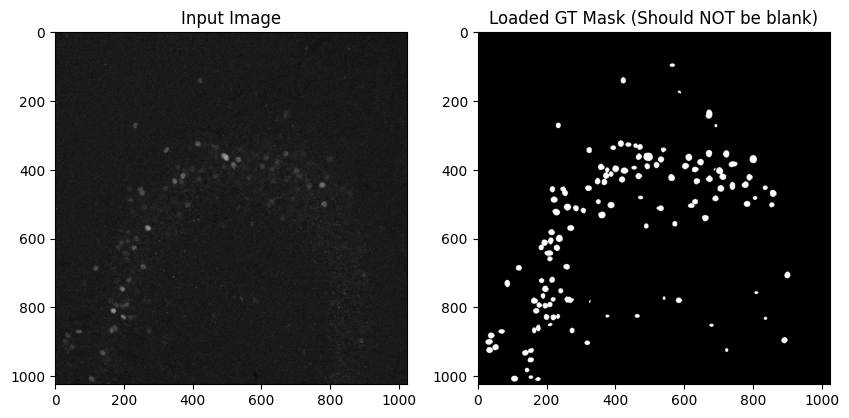

Mask unique values: tensor([0, 1])


In [6]:
import matplotlib.pyplot as plt

train_img_dir = "/content/drive/MyDrive/BUET_msc/Medical_Img/term_proj2/deepflash2-paper/data/cFOS_in_HC/train/images"
train_msk_dir = "/content/drive/MyDrive/BUET_msc/Medical_Img/term_proj2/output/cFOS_in_HC/train/masks_STAPLE"

# Initialize dataset
test_ds = CFOSDataset(train_img_dir, train_msk_dir)
img, msk = test_ds[0]

# Plot to verify
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img.numpy().transpose(1, 2, 0))
ax[0].set_title("Input Image")
ax[1].imshow(msk.numpy(), cmap='gray')
ax[1].set_title("Loaded GT Mask (Should NOT be blank)")
plt.show()

print(f"Mask unique values: {torch.unique(msk)}") # Should print [0, 1]

--- Training Model 1/5 ---
Model saved to: /content/drive/MyDrive/BUET_msc/Medical_Img/term_proj2/output/models/deepflash2_ensemble_model_fold_1.pth
--- Training Model 2/5 ---
Model saved to: /content/drive/MyDrive/BUET_msc/Medical_Img/term_proj2/output/models/deepflash2_ensemble_model_fold_2.pth
--- Training Model 3/5 ---
Model saved to: /content/drive/MyDrive/BUET_msc/Medical_Img/term_proj2/output/models/deepflash2_ensemble_model_fold_3.pth
--- Training Model 4/5 ---
Model saved to: /content/drive/MyDrive/BUET_msc/Medical_Img/term_proj2/output/models/deepflash2_ensemble_model_fold_4.pth
--- Training Model 5/5 ---
Model saved to: /content/drive/MyDrive/BUET_msc/Medical_Img/term_proj2/output/models/deepflash2_ensemble_model_fold_5.pth

--- Step 1: Absolute Performance (vs Estimated GT) ---
Ensemble Mean Dice Score: 1.0000
Ensemble Mean mAP: 0.8500

--- Step 2: Relative Performance (vs Experts) ---
Result: Model Dice (1.0000) is OUTSIDE expert range (0.66, 0.81).

--- Visualizing Result

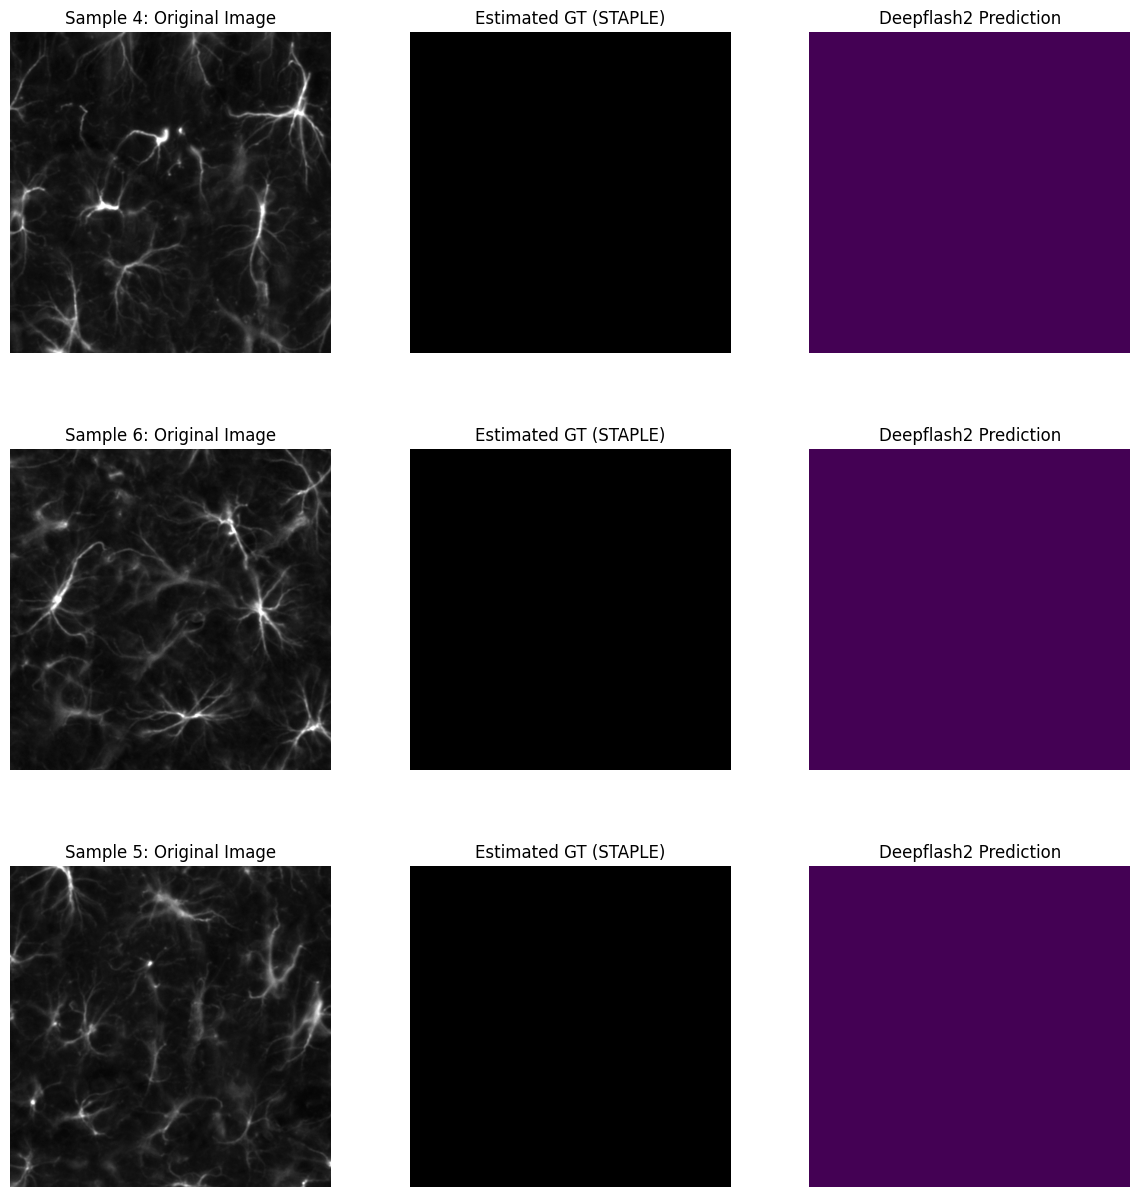

In [6]:
# ---------------------------------------------------------
# Execution Block
# ---------------------------------------------------------
if __name__ == "__main__":
    train_img_dir = "/content/drive/MyDrive/BUET_msc/Medical_Img/term_proj2/deepflash2-paper/data/GFAP_in_HC/train/images"
    train_msk_dir = "/content/drive/MyDrive/BUET_msc/Medical_Img/term_proj2/output/GFAP_in_HC/train/masks_STAPLE"

    test_img_dir = "/content/drive/MyDrive/BUET_msc/Medical_Img/term_proj2/deepflash2-paper/data/GFAP_in_HC/test/images"
    test_msk_dir = "/content/drive/MyDrive/BUET_msc/Medical_Img/term_proj2/output/GFAP_in_HC/test/masks_STAPLE" # Assuming GT exists here for evaluation

    # Placeholder for expert ranges calculated from individual annotators [cite: 74]
    expert_ranges = {
        'dice_range': (0.66, 0.81), # Based on cFOS in HC dataset from the paper [cite: 116]
        'map_range': (0.29, 0.41)   # Based on cFOS in HC dataset from the paper [cite: 116]
    }

    # Run pipeline
    trained_ensemble = train_ensemble(train_img_dir, train_msk_dir, num_models=5)
    evaluate_ensemble(trained_ensemble, test_img_dir, test_msk_dir, expert_ranges)